In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('infl_tweets.csv', index_col=0)
df.head()

,username,name,text,lang,in_reply_to,is_quote_status,retweeted_tweet,possibly_sensitive,favorited,date,...,view_count,view_count_state,retweet_count,place,is_translatable,edits_remaining,has_card,thumbnail_title,urls,hashtags
0,davidfaber,David Faber,LVMH sales not good led by 5% decline in Fashi...,en,NaN,False,NaN,NaN,False,2024-10-15 16:13:15+00:00,...,15275.0,EnabledWithCount,5,NaN,False,5.0,False,NaN,[],[]
1,davidfaber,David Faber,NYC losing another iconic restaurant: The 21 C...,en,NaN,False,NaN,0.0,False,2020-12-11 21:02:46+00:00,...,NaN,Enabled,791,NaN,False,5.0,False,NaN,[],[]
2,davidfaber,David Faber,⁦@DivesTech⁩ always brightens our day. https:/...,en,NaN,False,NaN,0.0,False,2023-08-29 14:43:53+00:00,...,39816.0,EnabledWithCount,8,NaN,False,5.0,False,NaN,[],[]
3,davidfaber,David Faber,Statement from PIF on PGA Commissioner Monahan...,en,NaN,False,NaN,0.0,False,2023-06-14 14:01:05+00:00,...,27073.0,EnabledWithCount,4,NaN,False,5.0,False,NaN,[],[]
4,davidfaber,David Faber,Steve Cohen has entered exclusive negotiations...,en,NaN,False,NaN,NaN,False,2020-08-29 01:53:26+00:00,...,NaN,Enabled,1059,NaN,False,5.0,False,NaN,[],[]


### Описание атрибутов ###
- **username** - Username
- **name** - Author of the tweet
- **text** - The full text of the tweet
- **lang** - The language of the tweet
- **in_reply_to** - The tweet ID this tweet is in reply to, if any
- **is_quote_status** - Indicates if the tweet is a quote status
- **retweeted_tweet** - The Tweet being retweeted (if any)
- **possibly_sensitive** - Indicates if the tweet content may be sensitive
- **favorited** - Indicates if the tweet is favorited
- **date** - The date and time when the tweet was created
- **quote_count** - The count of quotes for the tweet
- **reply_count** - The count of replies to the tweet
- **favorite_count** - The count of favorites or likes for the tweet
- **view_count** - The count of views
- **view_count_state** - The state of the tweet views
- **retweet_count** - The count of retweets for the tweet
- **place** - The location associated with the tweet
- **is_translatable** - Indicates if the tweet is translatable
- **edits_remaining** - The remaining number of edits allowed for the tweet
- **has_card** - Indicates if the tweet contains a card
- **thumbnail_title** - The title of the webpage displayed inside the tweet’s card
- **urls** - Information about URLs contained in the tweet
- **hashtags** - Hashtags included in the tweet text

### Количество собранных твитов ###

In [3]:
df.shape[0]

11820

### Самые популярные слова ###

In [4]:
from nltk.tokenize import TweetTokenizer
from string import punctuation
from nltk.corpus import stopwords

tw = TweetTokenizer()

special_symbols = ['“', '’', '”', '…', '...']
noise = stopwords.words("english") + list(punctuation) + special_symbols

def remove_stop_words(x):
    res = []
    for token in tw.tokenize(x.lower()):
        if token not in noise:
            res.append(token)
    return res

/tmp/ipykernel_318167/353653197.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


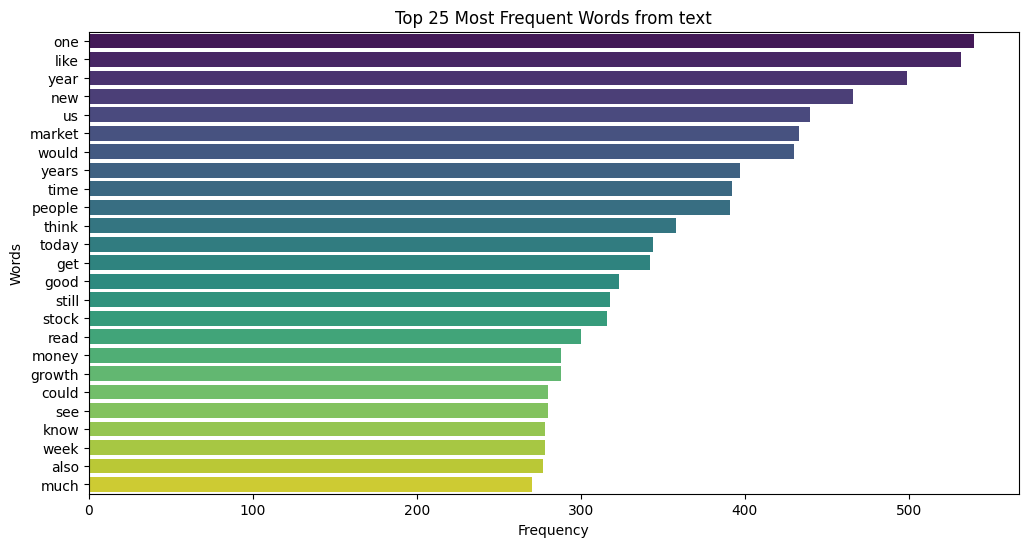

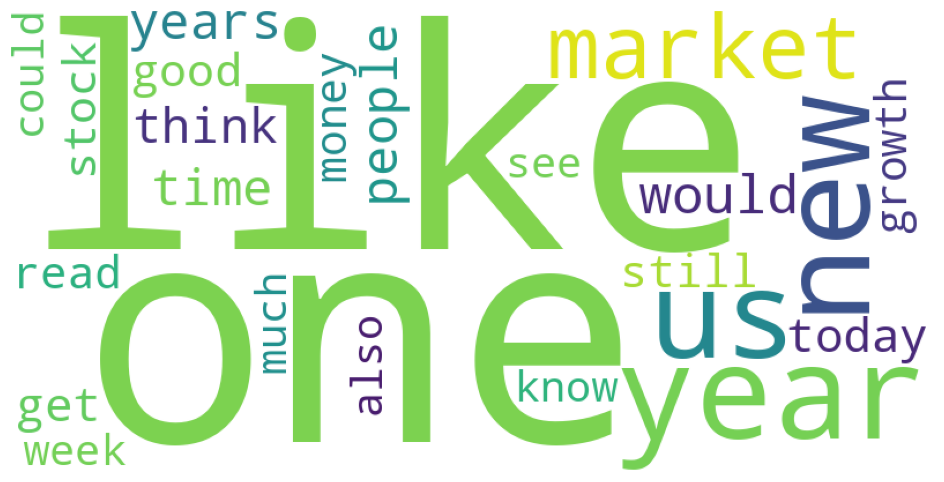

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

def process_text_att(data, col_name, top_count=25):
    word_counts = data[col_name].apply(remove_stop_words).explode().value_counts()[:top_count]
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts.to_dict())
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {top_count} Most Frequent Words from {data[col_name].name}')
    plt.show()
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

process_text_att(df, 'text')

### Создание атрибута ticker ###

Данная модель находит тикер или название компании в тексте, но у нее есть один существенный недостаток - если в тексте упомянут более чем один тикер, модель его не находит. При попытке разделить текст на части и для каждой из них запускать модель, возникают несуществущие тикеры и названия компаний.

In [6]:
# from transformers import AutoTokenizer, AutoModelForTokenClassification

# tokenizer = AutoTokenizer.from_pretrained("Jean-Baptiste/roberta-ticker")
# model = AutoModelForTokenClassification.from_pretrained("Jean-Baptiste/roberta-ticker")

# from transformers import pipeline

# nlp = pipeline('ner', model=model, tokenizer=tokenizer, aggregation_strategy="simple")
 

In [7]:
# df.loc[3]['text']

In [8]:
# nlp(df.loc[3]['text'])

Нахождение тикера с помощью регулярного выражения:

In [9]:
import sys
sys.path.append('/home/vasily/futures-price-prediction/')

from load_quotes import LIST_OF_TICKERS_1, LIST_OF_TICKERS_2, LIST_OF_TICKERS_3, LIST_OF_TICKERS_4, LIST_OF_TICKERS_5, LIST_OF_TICKERS_6

In [10]:
def read_file(path):
    with open(path, mode='r') as file:
        return [line.split() for line in file.readlines()]
    
read_file('../comps/comp_usernames_1')

[['AAPL', '@Apple', 'Apple'],
 ['META', '@meta', 'meta', 'Meta'],
 ['NVDA', '@nvidia', 'NVIDIA', 'Nvidia'],
 ['AMD', '@AMD', 'amd'],
 ['GOOG', '@google', 'Google', 'google'],
 ['XOM', '@exxonmobil'],
 ['MCD', '@McDonalds', 'McDonalds'],
 ['KO', '@CocaCola', 'CocaCola'],
 ['PFE', '@Pfizer', 'Pfizer'],
 ['PG', '@ProcterGamble', 'ProcterGamble']]

В твитах компания не всегда упомянается через тикер. Иногда можно встретить полное название компании или же ее юзернейм. Исходя из этого, лучше обрабатывать все возможное варианты упоминаний компании, но в этом подходе есть своя сложность, заключающаяся в том, что наименования компании приходится вводить вручную.

In [11]:
TICKERS = read_file('../comps/comp_usernames_1') + read_file('../comps/comp_usernames_2') + [[ticker] for ticker in LIST_OF_TICKERS_3] + [[ticker] for ticker in LIST_OF_TICKERS_4] + [[ticker] for ticker in LIST_OF_TICKERS_5] + [[ticker] for ticker in LIST_OF_TICKERS_6]

In [12]:
TICKERS

[['AAPL', '@Apple', 'Apple'],
 ['META', '@meta', 'meta', 'Meta'],
 ['NVDA', '@nvidia', 'NVIDIA', 'Nvidia'],
 ['AMD', '@AMD', 'amd'],
 ['GOOG', '@google', 'Google', 'google'],
 ['XOM', '@exxonmobil'],
 ['MCD', '@McDonalds', 'McDonalds'],
 ['KO', '@CocaCola', 'CocaCola'],
 ['PFE', '@Pfizer', 'Pfizer'],
 ['PG', '@ProcterGamble', 'ProcterGamble'],
 ['MSFT'],
 ['AMZN', '@amazonnews'],
 ['TSLA', '@Tesla'],
 ['GOOGL', '@google'],
 ['JPM'],
 ['JNJ', '@JNJNews'],
 ['V'],
 ['CMCSA', '@comcast'],
 ['PEP', '@PepsiCo'],
 ['T', '@ATT'],
 ['CSCO', '@Cisco'],
 ['DIS'],
 ['NKE', '@Nike'],
 ['VZ', '@verizonfios'],
 ['HD', '@HomeDepot'],
 ['UNH', '@UnitedHealthGrp'],
 ['CRM', '@salesforceapac'],
 ['NFLX', '@netflix'],
 ['INTC', '@intel'],
 ['BA', '@Boeing'],
 ['MRK', '@Merck'],
 ['LMT', '@LockheedMartin'],
 ['GILD', '@GileadSciences'],
 ['SBUX', '@Starbucks'],
 ['AMGN'],
 ['IBM'],
 ['HON'],
 ['PYPL'],
 ['LRCX'],
 ['MDLZ'],
 ['BKNG'],
 ['FDX'],
 ['EOG'],
 ['CIM'],
 ['DVN'],
 ['MPC'],
 ['CHK'],
 ['RRC'],
 

In [13]:
import regex as re

def is_ticker(x, ticker):
    prog = re.compile(f'(?<!\S)\$?{ticker}(?!\S)')
    res = prog.findall(x)
    return len(res) != 0

df['ticker'] = [[] for _ in range(df.shape[0])]

for names in TICKERS:
    for name in names:
        df['ticker'] = df.apply(lambda x: x['ticker'] + [names[0]] if is_ticker(x['text'], name) else x['ticker'], axis=1)
    
df['ticker'] = df['ticker'].apply(lambda x: None if len(x) == 0 else x)

In [14]:
df = df.explode('ticker')

In [15]:
df = df.dropna(subset=['ticker'])

In [16]:
df = df.reset_index().drop('index', axis=1)

In [17]:
df['ticker'] = df['ticker'].apply(lambda x: x[1:] if '$' in x else x)

Дата сет с размеченными тикерами:

In [18]:
df.head()

,username,name,text,lang,in_reply_to,is_quote_status,retweeted_tweet,possibly_sensitive,favorited,date,...,view_count_state,retweet_count,place,is_translatable,edits_remaining,has_card,thumbnail_title,urls,hashtags,ticker
0,davidfaber,David Faber,The chance of $MSFT winning an appeal of the ...,en,NaN,False,NaN,0.0,False,2023-04-26 12:23:58+00:00,...,EnabledWithCount,19,NaN,False,5.0,False,NaN,[],[],MSFT
1,PhilipEtienne,Voltaire,We love and appreciate all the volunteers at t...,en,NaN,False,NaN,0.0,False,2024-05-06 13:54:43+00:00,...,EnabledWithCount,1,NaN,False,5.0,False,NaN,[],[],NVDA
2,PhilipEtienne,Voltaire,Today walking the lab on the NJ beach - tomorr...,en,NaN,False,NaN,0.0,False,2024-05-08 13:11:46+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],META
3,PhilipEtienne,Voltaire,Today walking the lab on the NJ beach - tomorr...,en,NaN,False,NaN,0.0,False,2024-05-08 13:11:46+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],NVDA
4,PhilipEtienne,Voltaire,Good Morning from a dog walk on the $NVDA resc...,en,NaN,False,NaN,0.0,False,2024-05-05 13:56:44+00:00,...,EnabledWithCount,0,NaN,False,5.0,False,NaN,[],[],NVDA


Размер дата сета

In [19]:
df.shape

(528, 24)

### Тикеры самых упомянаемых компаний ###

/tmp/ipykernel_318167/265398946.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticker_count.values, y=ticker_count.index, palette='viridis')


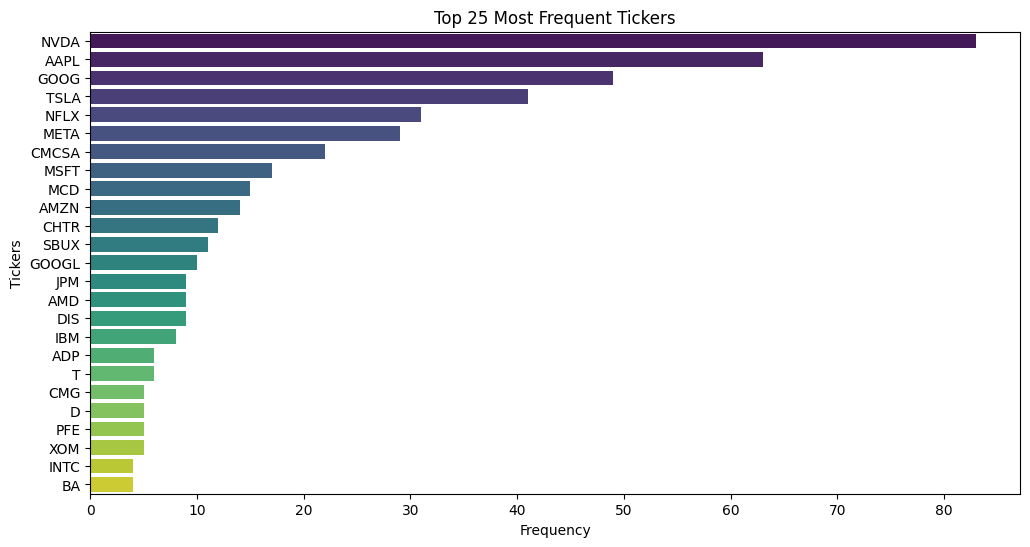

In [20]:
ticker_count = df['ticker'].value_counts()[:25]

plt.figure(figsize=(12, 6))
sns.barplot(x=ticker_count.values, y=ticker_count.index, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Tickers')
plt.title('Top 25 Most Frequent Tickers')
plt.show()

### date ###

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [22]:
df['date']

0     2023-04-26 12:23:58+00:00
1     2024-05-06 13:54:43+00:00
2     2024-05-08 13:11:46+00:00
3     2024-05-08 13:11:46+00:00
4     2024-05-05 13:56:44+00:00
                 ...           
523   2024-10-25 21:04:57+00:00
524   2024-09-23 14:04:14+00:00
525   2024-10-28 10:51:25+00:00
526   2024-10-24 13:17:26+00:00
527   2024-08-23 18:13:51+00:00
Name: date, Length: 528, dtype: datetime64[ns, UTC]

In [23]:
df['date'].min()

Timestamp('2015-08-21 19:38:04+0000', tz='UTC')

In [24]:
df['day'] = df['date'].apply(lambda x: x.day)
df['month'] = df['date'].apply(lambda x: x.month)
df['year'] = df['date'].apply(lambda x: x.year)

In [25]:
df['year'].name

'year'

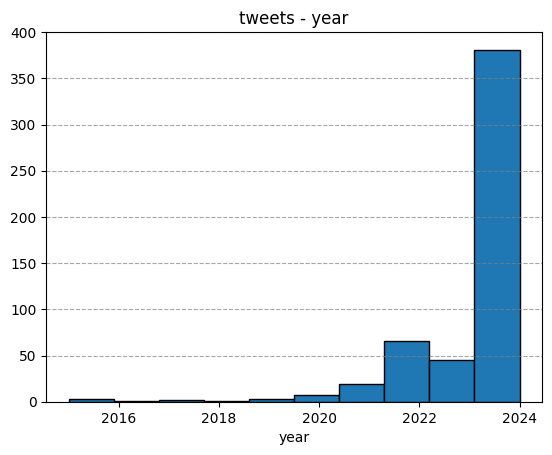

In [26]:
def create_hist(x, x_bins=None):  
    fig, ax = plt.subplots()
       
    ax.hist(x, edgecolor='black', bins=x_bins)    
      
    ax.grid(True, which='both', axis='y', linestyle='--', color='gray', alpha=0.7)    
    ax.set_xlabel(x.name)   
    ax.set_title(f'tweets - {x.name}')    
    plt.show()
    
create_hist(df['year'])

### Общие сведенья о данных ###

In [27]:
df.describe()

,in_reply_to,retweeted_tweet,possibly_sensitive,quote_count,reply_count,favorite_count,view_count,retweet_count,place,edits_remaining,day,month,year
count,1.290000e+02,0.0,299.0,528.000000,528.000000,528.000000,4.260000e+02,528.000000,0.0,524.0,528.000000,528.000000,528.000000
mean,1.668378e+18,NaN,0.0,7.064394,14.903409,218.287879,4.818457e+04,27.392045,NaN,5.0,17.615530,8.051136,2023.371212
std,1.848504e+17,NaN,0.0,60.853665,74.320248,1334.763003,2.350530e+05,189.626687,NaN,0.0,8.321682,3.027897,1.306270
min,7.851227e+17,NaN,0.0,0.000000,0.000000,0.000000,2.200000e+01,0.000000,NaN,5.0,1.000000,1.000000,2015.000000
25%,1.533059e+18,NaN,0.0,0.000000,0.000000,3.000000,1.901750e+03,0.000000,NaN,5.0,11.000000,6.750000,2023.000000
50%,1.697258e+18,NaN,0.0,0.000000,1.000000,14.000000,6.255000e+03,1.000000,NaN,5.0,17.000000,10.000000,2024.000000
75%,1.829605e+18,NaN,0.0,1.000000,5.000000,47.500000,2.451175e+04,8.000000,NaN,5.0,24.250000,10.000000,2024.000000
max,1.851577e+18,NaN,0.0,1263.000000,1532.000000,22396.000000,4.559190e+06,3753.000000,NaN,5.0,30.000000,12.000000,2024.000000


In [28]:
df.describe(include='object')

,username,name,text,lang,view_count_state,thumbnail_title,urls,hashtags,ticker
count,528,528,528,528,528,76,528,528,528
unique,71,71,404,8,2,67,132,15,63
top,Find_Me_Value,FMV,"It's a MEGA earnings week, with Alphabet $GOOG...",en,EnabledWithCount,"527: Zuck Trying to Osborne Apple, Orion AR, S...",[],[],NVDA
freq,81,81,7,519,426,3,351,510,83


In [29]:
df.isna().sum()

username                0
name                    0
text                    0
lang                    0
in_reply_to           399
is_quote_status         0
retweeted_tweet       528
possibly_sensitive    229
favorited               0
date                    0
quote_count             0
reply_count             0
favorite_count          0
view_count            102
view_count_state        0
retweet_count           0
place                 528
is_translatable         0
edits_remaining         4
has_card                0
thumbnail_title       452
urls                    0
hashtags                0
ticker                  0
day                     0
month                   0
year                    0
dtype: int64

In [30]:
df.columns

Index(['username', 'name', 'text', 'lang', 'in_reply_to', 'is_quote_status',
       'retweeted_tweet', 'possibly_sensitive', 'favorited', 'date',
       'quote_count', 'reply_count', 'favorite_count', 'view_count',
       'view_count_state', 'retweet_count', 'place', 'is_translatable',
       'edits_remaining', 'has_card', 'thumbnail_title', 'urls', 'hashtags',
       'ticker', 'day', 'month', 'year'],
      dtype='object')

### username и name ###

Для идентификации автора твита достотачно одного из этих двух признаков.

In [31]:
df = df.drop('name', axis=1)

### text ###

Процент твитов с упомянанием нескольких компаний от общего кол-ва твитов:

In [32]:
(df.shape[0] - df['text'].unique().shape[0]) / df.shape[0]

0.23484848484848486

### lang ###

Уникальные значения:

In [33]:
df['lang'].unique()

array(['en', 'lv', 'sv', 'qct', 'es', 'fr', 'und', 'qme'], dtype=object)

In [34]:
for lang in df['lang'].unique():
    text_sample = df[df['lang'] == lang].iloc[0]['text']
    print(f'{lang = }: {text_sample}')

lang = 'en': The chance of $MSFT winning an  appeal of the negative ruling from the CMA are exceedingly slim. Per UBS, the Competition Appeal Tribunal that would hear an appeal has not ruled in favor of merging parties for years. Appeal could also take a year.Getting very close to "all dead". https://t.co/3bGHnuM1b7
lang = 'lv': Tesla, $TSLA unveils "Robovan" https://t.co/2WipLfdtIE
lang = 'sv': @asharoraa meta dinner!
lang = 'qct': $GOOG
lang = 'es': $NFLX slide - consolidation in Media Landscape https://t.co/wYOH2IWrqE
lang = 'fr': Chart crime nomination - $T https://t.co/iNEK4e0dS6
lang = 'und': $CMG 2016
lang = 'qme': 🤔

$SBUX $CMG


Кодировка языков официального API твитера https://developer.x.com/en/docs/x-for-websites/supported-languages не совпадает с кодировкой из библиотеки Twikit, с помощью которой были собранны данные.

В документации библиотеки Twikit, мне не удалось найти информации о кодировки языков, поэтому я решил убрать признак lang из дата сета, с учетом того, что судя по всему большинство данных сокращения не относятся к языкам или же они все-таки соответсвуют кодировки языков, но по неизвестной мне ошибке выводятся неккорректно. 

Далее примем, что все твиты написаны на английском языке. Это допущение можно сделать, поскольку данные собраны из англоязычных источников.

In [35]:
df = df.drop('lang', axis=1)

### in_reply_to ###

Заменем признак in_reply_to на признак is_in_reply_to, указывающий на тип твита, является он ответом на другой твит или нет: ответ (1), иначе (0). В целом, было бы полезно узнать информацию о твите, на который был отправлен ответ, но данный датасет такой информации в себе не хранит.

In [36]:
df['is_in_reply_to'] = df['in_reply_to'].fillna(0).apply(lambda x: 0 if x == 0 else 1)
df.drop('in_reply_to', axis=1, inplace=True)

### retweeted_tweet ###

In [37]:
df['retweeted_tweet'].unique()

array([nan])

На данном этапе этот признак не содержит данных. Оставим его без изменений.

Далее все признаки с отсутвующими значениями или же имеющие только одно значения будут оставаться без изменений, но при построении модели они будут удалены из выборки.

### Обработка bool признаков ###

In [38]:
df.select_dtypes(include='bool').columns

Index(['is_quote_status', 'favorited', 'is_translatable', 'has_card'], dtype='object')

In [39]:
for col_name in df.columns:
    if df[col_name].dtypes == bool:
        df[col_name] = df[col_name].apply(int)

### possibly_sensitive ###

In [40]:
df['possibly_sensitive'].unique()

array([ 0., nan])

In [41]:
df['possibly_sensitive'] = df['possibly_sensitive'].fillna(0.)

### favorited ###

In [42]:
df['favorited'].unique()

array([0])

### _count признаки ###

view_count_state это категориальный признак, он показывает доступность получения информации о просмотренных твитах. Этот признак содержит только две категории, поэтому его можно перекодировать в бинарный - 1, если кол-во просмотров доступно; 0, если кол-во твитов недоступно.

In [43]:
df['is_view_count'] = df['view_count_state'].apply(lambda x: 1 if x == 'EnabledWithCount' else 0)
df = df.drop('view_count_state', axis=1)

Остальные _count признаки являеются численными.

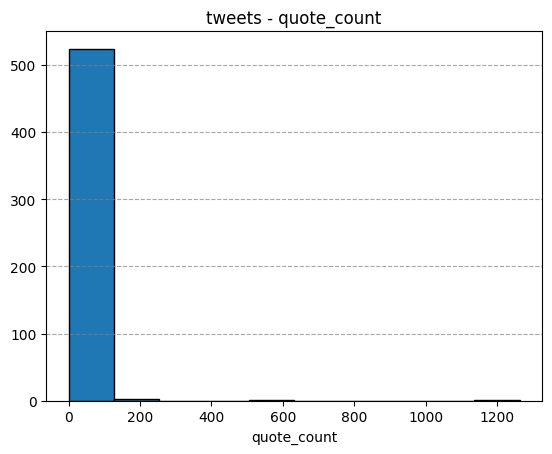

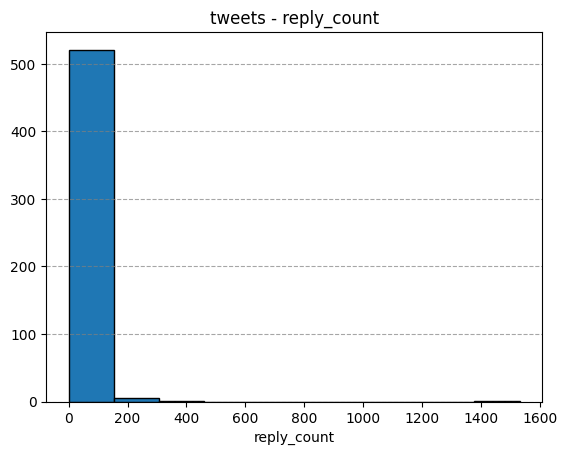

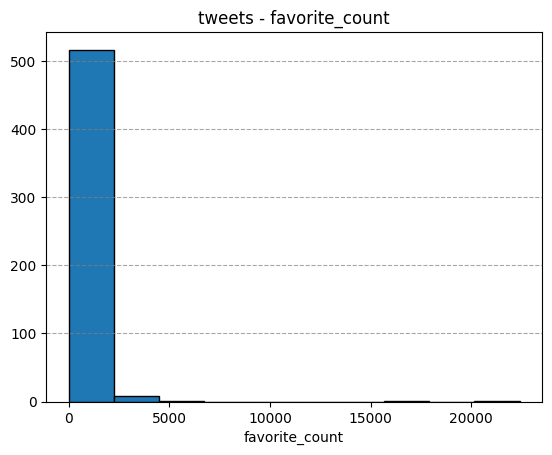

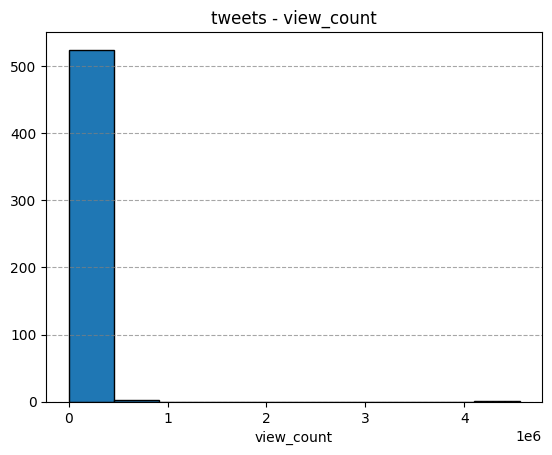

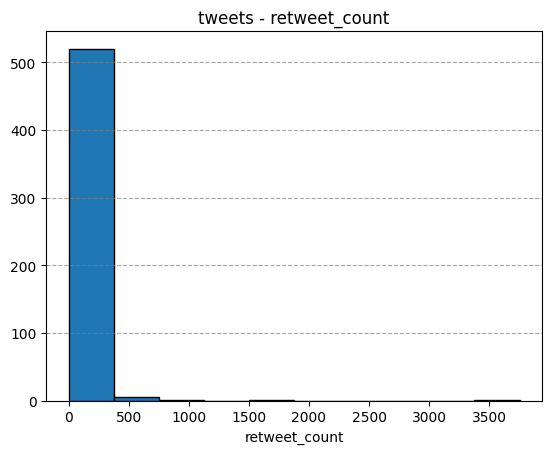

In [44]:
count_att = ['quote_count', 'reply_count', 'favorite_count', 'view_count', 'retweet_count']

for col_name in count_att:
    df[col_name] = df[col_name].fillna(0)
    create_hist(df[col_name])

Рассмотрим распределение данных без выбросов: 

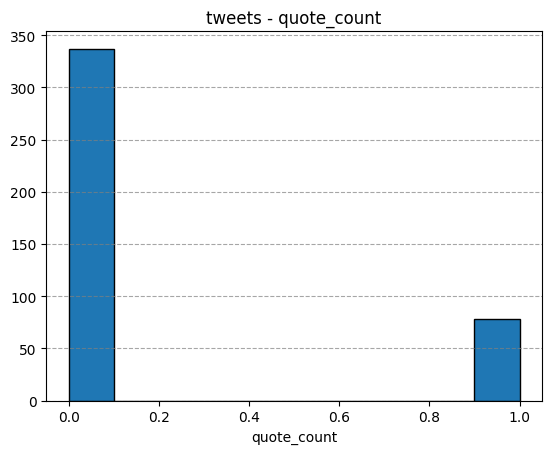

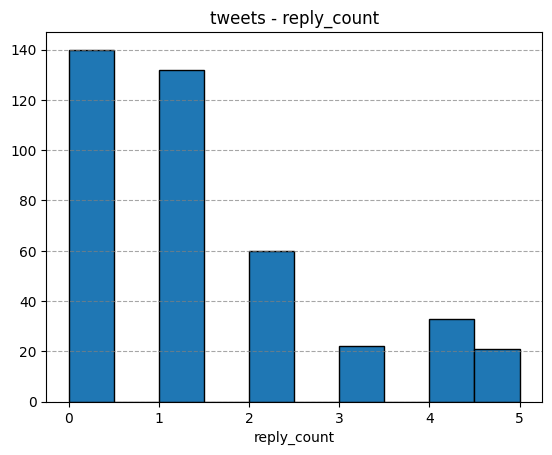

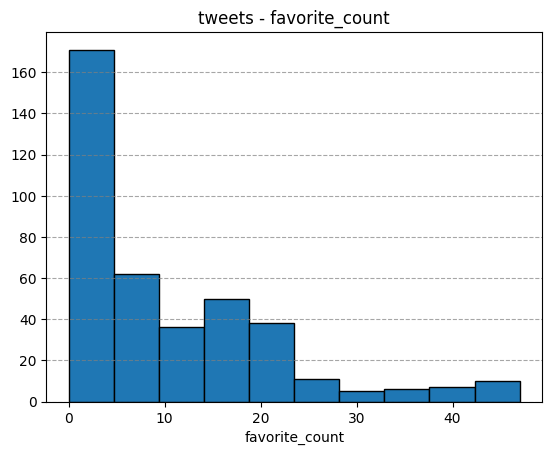

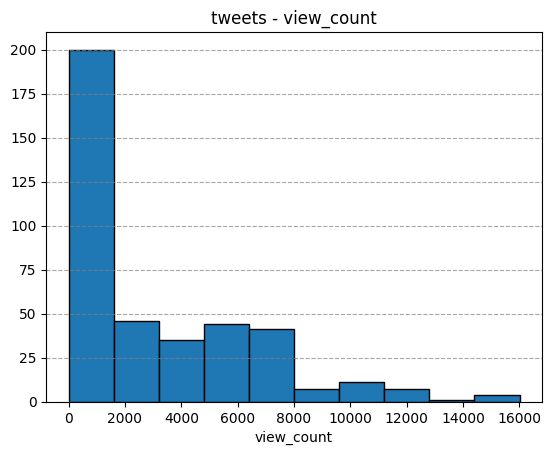

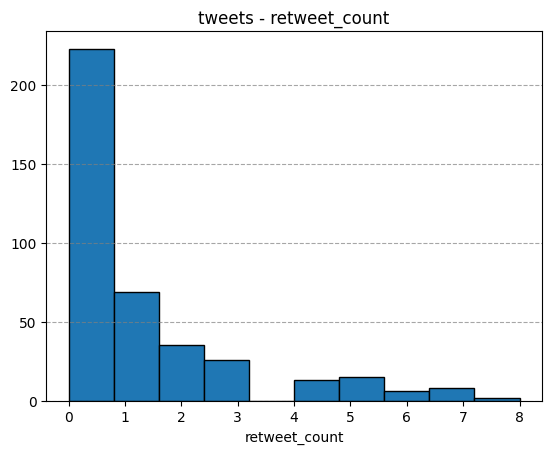

In [45]:
for col_name in count_att:
    create_hist(df[df[col_name] <= df[col_name].quantile(0.75)][col_name])

### place ###

Признак place был добавлен для обратной совместимости с предыдущей версией датасета. Его можно удалить, поскольку он изначально не содержит никакой информации.

In [46]:
df = df.drop('place', axis=1)

### edits_remaining ###

In [47]:
df['edits_remaining'].unique()

array([ 5., nan])

Максимальное число оставшихся попыток равно 5.

In [48]:
df['edits_remaining'] = df['edits_remaining'].fillna(5)

### thumbnail_title ###

In [49]:
df['thumbnail_title'] = df['thumbnail_title'].fillna('')

/tmp/ipykernel_318167/353653197.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


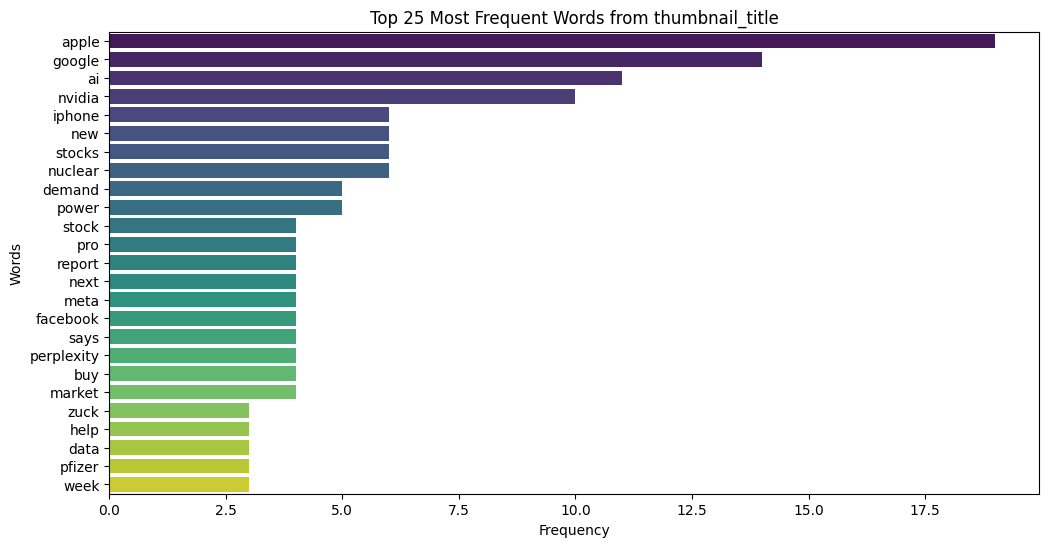

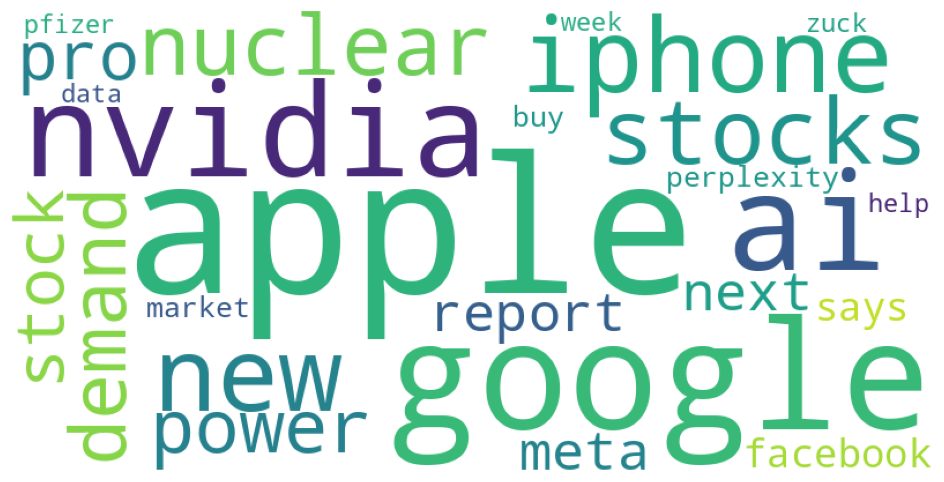

In [50]:
process_text_att(df, 'thumbnail_title')

### urls ###

Упростим этот признак до проверки наличия ссылок в твите.

In [51]:
df['urls'] = df['urls'].apply(lambda x: 1 if x != '[]' else 0)

### hashtags ###

In [52]:
df['hashtags'].unique()

array(['[]', "['dividendstocks']", "['ElonMusk']", "['Sahm']",
       "['Lennar', 'Florida']", "['AI']", "['fridaynightdump']",
       "['Nike']", "['toosoon']", "['IBM', 'Earnings', 'Tech']",
       "['AI', 'StockMarket', 'investing']",
       "['Investing', 'DowJones', 'StockMarket']",
       "['StockMarket', 'FedRateCut', 'TechStocks']",
       "['Microsoft', 'Dividends', 'StockMarket']",
       "['NVIDIA', 'StockMarket', 'Investing']"], dtype=object)

Преобразуем список хештегов в формат строки

In [53]:
df['hashtags'] = df['hashtags'].apply(lambda x: ' '.join(eval(x)))

/tmp/ipykernel_318167/353653197.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_counts.values, y=word_counts.index, palette='viridis')


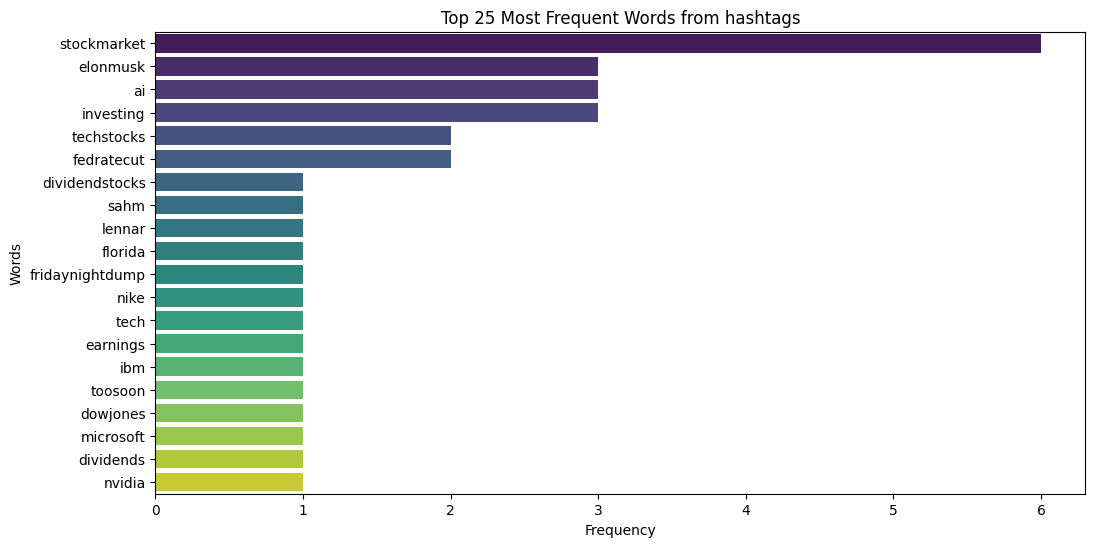

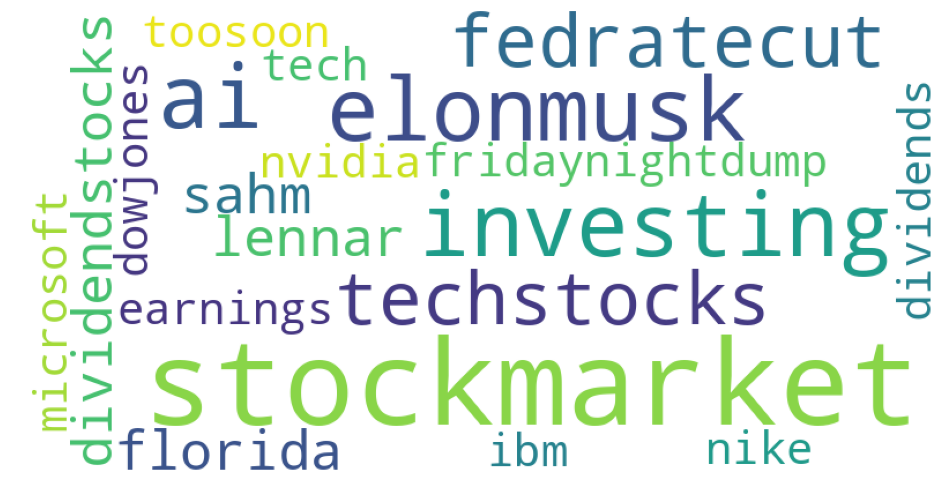

In [54]:
process_text_att(df, 'hashtags')

### Удаление признаков с одним значением ### 

In [55]:
for col_name in df.columns:
    if df[col_name].unique().shape[0] == 1:
        df = df.drop(col_name, axis=1)
        print(f'{col_name} deleted')

retweeted_tweet deleted
possibly_sensitive deleted
favorited deleted
is_translatable deleted
edits_remaining deleted


### Добавление данных о котировках ###

In [56]:
import pandas as pd

In [57]:
qs0 = pd.read_csv('../../quotes/quotes.csv')
qs1 = pd.read_csv('../../quotes/quotes_08-11-2024.csv')
qs2 = pd.read_csv('../../quotes/quotes_08-11-2024_1.csv')

qs0 = qs0.drop(['Unnamed: 0', 'id'], axis=1).rename({'quote_date': 'date'}, axis=1)[qs1.columns]
qs = pd.concat([qs0, qs1, qs2])

qs['date'] = pd.to_datetime(qs['date'])
qs = qs.drop(['high', 'low', 'volume'], axis=1)
qs = qs.drop_duplicates().reset_index(drop='first')

qs.head()

,date,open,close,ticker
0,2024-10-18,236.18,235.00,AAPL
1,2024-10-17,233.43,232.15,AAPL
2,2024-10-16,231.60,231.78,AAPL
3,2024-10-15,233.61,233.85,AAPL
4,2024-10-14,228.70,231.30,AAPL


In [72]:
def open_price(X, Q):
    '''
    Возвращает модифицированный датасет X c новыми 
    аттрибутами quote_date и open, полученными из
    датасета с котировками Q.
    
    open - цена открытия в день публикации или в 
    первый доступный день до этой даты
    
    quote_date - дата котировки 
    '''
    def func(x):
        '''
        Возвращает котировку, соответвующую 
        дате и тикеру из x. Если такой котировки
        нет, возвращается значение None
        '''
        current_date = str(x['date'].date())
        ticker_name = x['ticker']
        filtered = Q[(Q['date'] <= current_date) & (Q['ticker'] == ticker_name)].sort_values(by='date', ascending=False)
        if filtered.empty:
            return None
        return filtered.iloc[0]
        
    buf = X.apply(func, axis=1).rename({'date': 'quote_date'}, axis=1).drop(['close', 'ticker'], axis=1)
    
    return pd.concat([X, buf], axis=1)

In [71]:
df = open_price(df, qs)

Проверка пропусков

In [69]:
df.isna().sum()

username           0
text               0
is_quote_status    0
date               0
quote_count        0
reply_count        0
favorite_count     0
view_count         0
retweet_count      0
has_card           0
thumbnail_title    0
urls               0
hashtags           0
ticker             0
day                0
month              0
year               0
is_in_reply_to     0
is_view_count      0
quote_date         0
open               0
dtype: int64

### Выводы ###

- Размеченный датасет получился слишком мальнький для обучения модели только на данных из твиттера. В текущем состоянии его можно использовать в качестве дополнительных данных для более объемной модели.
- Проблема малого кол-ва объектов в дата сете связана в первую очередь с не самым оптимальным подходом для сбора данных из твитера. Так же это связано с недостатком наименований компаний на этапе выявления тикеров из уже собранных твитов.

### Что можно исправить? ###

- Оптимизировать парсер
- Добавить больше наименований компаний